# Support Ticket Baseline Classification Model

In this notebook, I build and evaluate a baseline text classification model for support ticket category prediction.

## Load the Data

In [1]:
import pandas as pd

X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv")
y_test = pd.read_csv("../data/y_test.csv")

train_df = X_train.merge(y_train, on="id")
test_df = X_test.merge(y_test, on="id")

print("Τα δεδομένα φορτώθηκαν σωστά")
print(train_df.shape)
print(test_df.shape)

Τα δεδομένα φορτώθηκαν σωστά
(1572, 3)
(657, 3)


## Prepare Features and Labels

In [2]:
X_train_text = train_df["text"]
X_test_text = test_df["text"]

y_train_labels = train_df["category_truth"]
y_test_labels = test_df["category_truth"]

print(X_train_text.shape)
print(y_train_labels.shape)

(1572,)
(1572,)


## Import Modeling Tools

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

## Build the Baseline Model

In [4]:
model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1000))
])

## Train the Model

In [5]:
model.fit(X_train_text, y_train_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## Generate Predictions

In [7]:
y_pred = model.predict(X_test_text)

## Compare Actual vs Predicted Labels

In [8]:
pd.DataFrame({
    "actual": y_test_labels.values,
    "predicted": y_pred
}).head(10)

,actual,predicted
0,Support general,Support general
1,Fileservice,Support general
2,Software,Support general
3,EOL,EOL
4,Fileservice,Fileservice
5,EOL,EOL
6,Software,Support general
7,Support general,Support general
8,Support general,Support general
9,Fileservice,Fileservice


## Evaluate Model Performance

In [9]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test_labels, y_pred)

0.7579908675799086

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test_labels, y_pred))

                   precision    recall  f1-score   support

 Active Directory       1.00      0.22      0.37        49
Computer-Services       0.95      0.49      0.65        41
              EOL       1.00      1.00      1.00        58
      Fileservice       0.99      0.92      0.95       138
             O365       0.86      0.48      0.62        92
         Software       0.74      0.40      0.52        58
  Support general       0.60      0.97      0.74       221

         accuracy                           0.76       657
        macro avg       0.88      0.64      0.69       657
     weighted avg       0.82      0.76      0.74       657



## Visualize Misclassifications

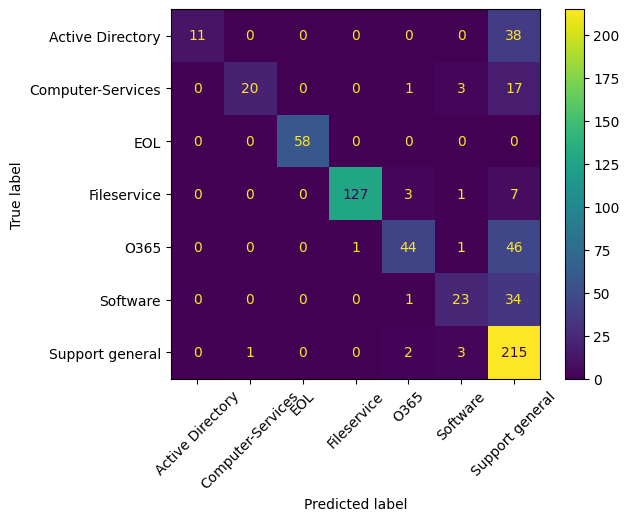

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_labels, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(xticks_rotation=45)
plt.show()

## Key Findings

- A baseline TF-IDF + Logistic Regression model achieved about 75.8% accuracy on the test set.
- The model performed especially well on Fileservice and EOL tickets.
- Several categories, including Active Directory, O365, Software, and Computer-Services, were often misclassified as Support general.
- This suggests that Support general acts as a broad fallback category for the model.
- A second TF-IDF setup with unigrams and bigrams did not improve performance over the simpler baseline.

## What I Found in the Data

- The dataset contains 7 ticket categories.
- Fileservice and Support general are the dominant categories, together covering about 69% of the training data.
- Most ticket texts are short, although a small number of much longer tickets are present.
- Ticket length varies across categories, with EOL tickets being notably longer on average.
- The dataset contains a substantial number of repeated or template-based ticket texts.